In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Dataset/online_shoppers_intention.csv')
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
import os
os.listdir()

['Combo.ipynb',
 'Dataset',
 'Dataset.zip',
 'Decision_Tree.ipynb',
 'EDA',
 'K_means.ipynb',
 'Logistic Regression.ipynb']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [4]:
lst_col = df.columns.tolist()
lst_col

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'Month',
 'OperatingSystems',
 'Browser',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend',
 'Revenue']

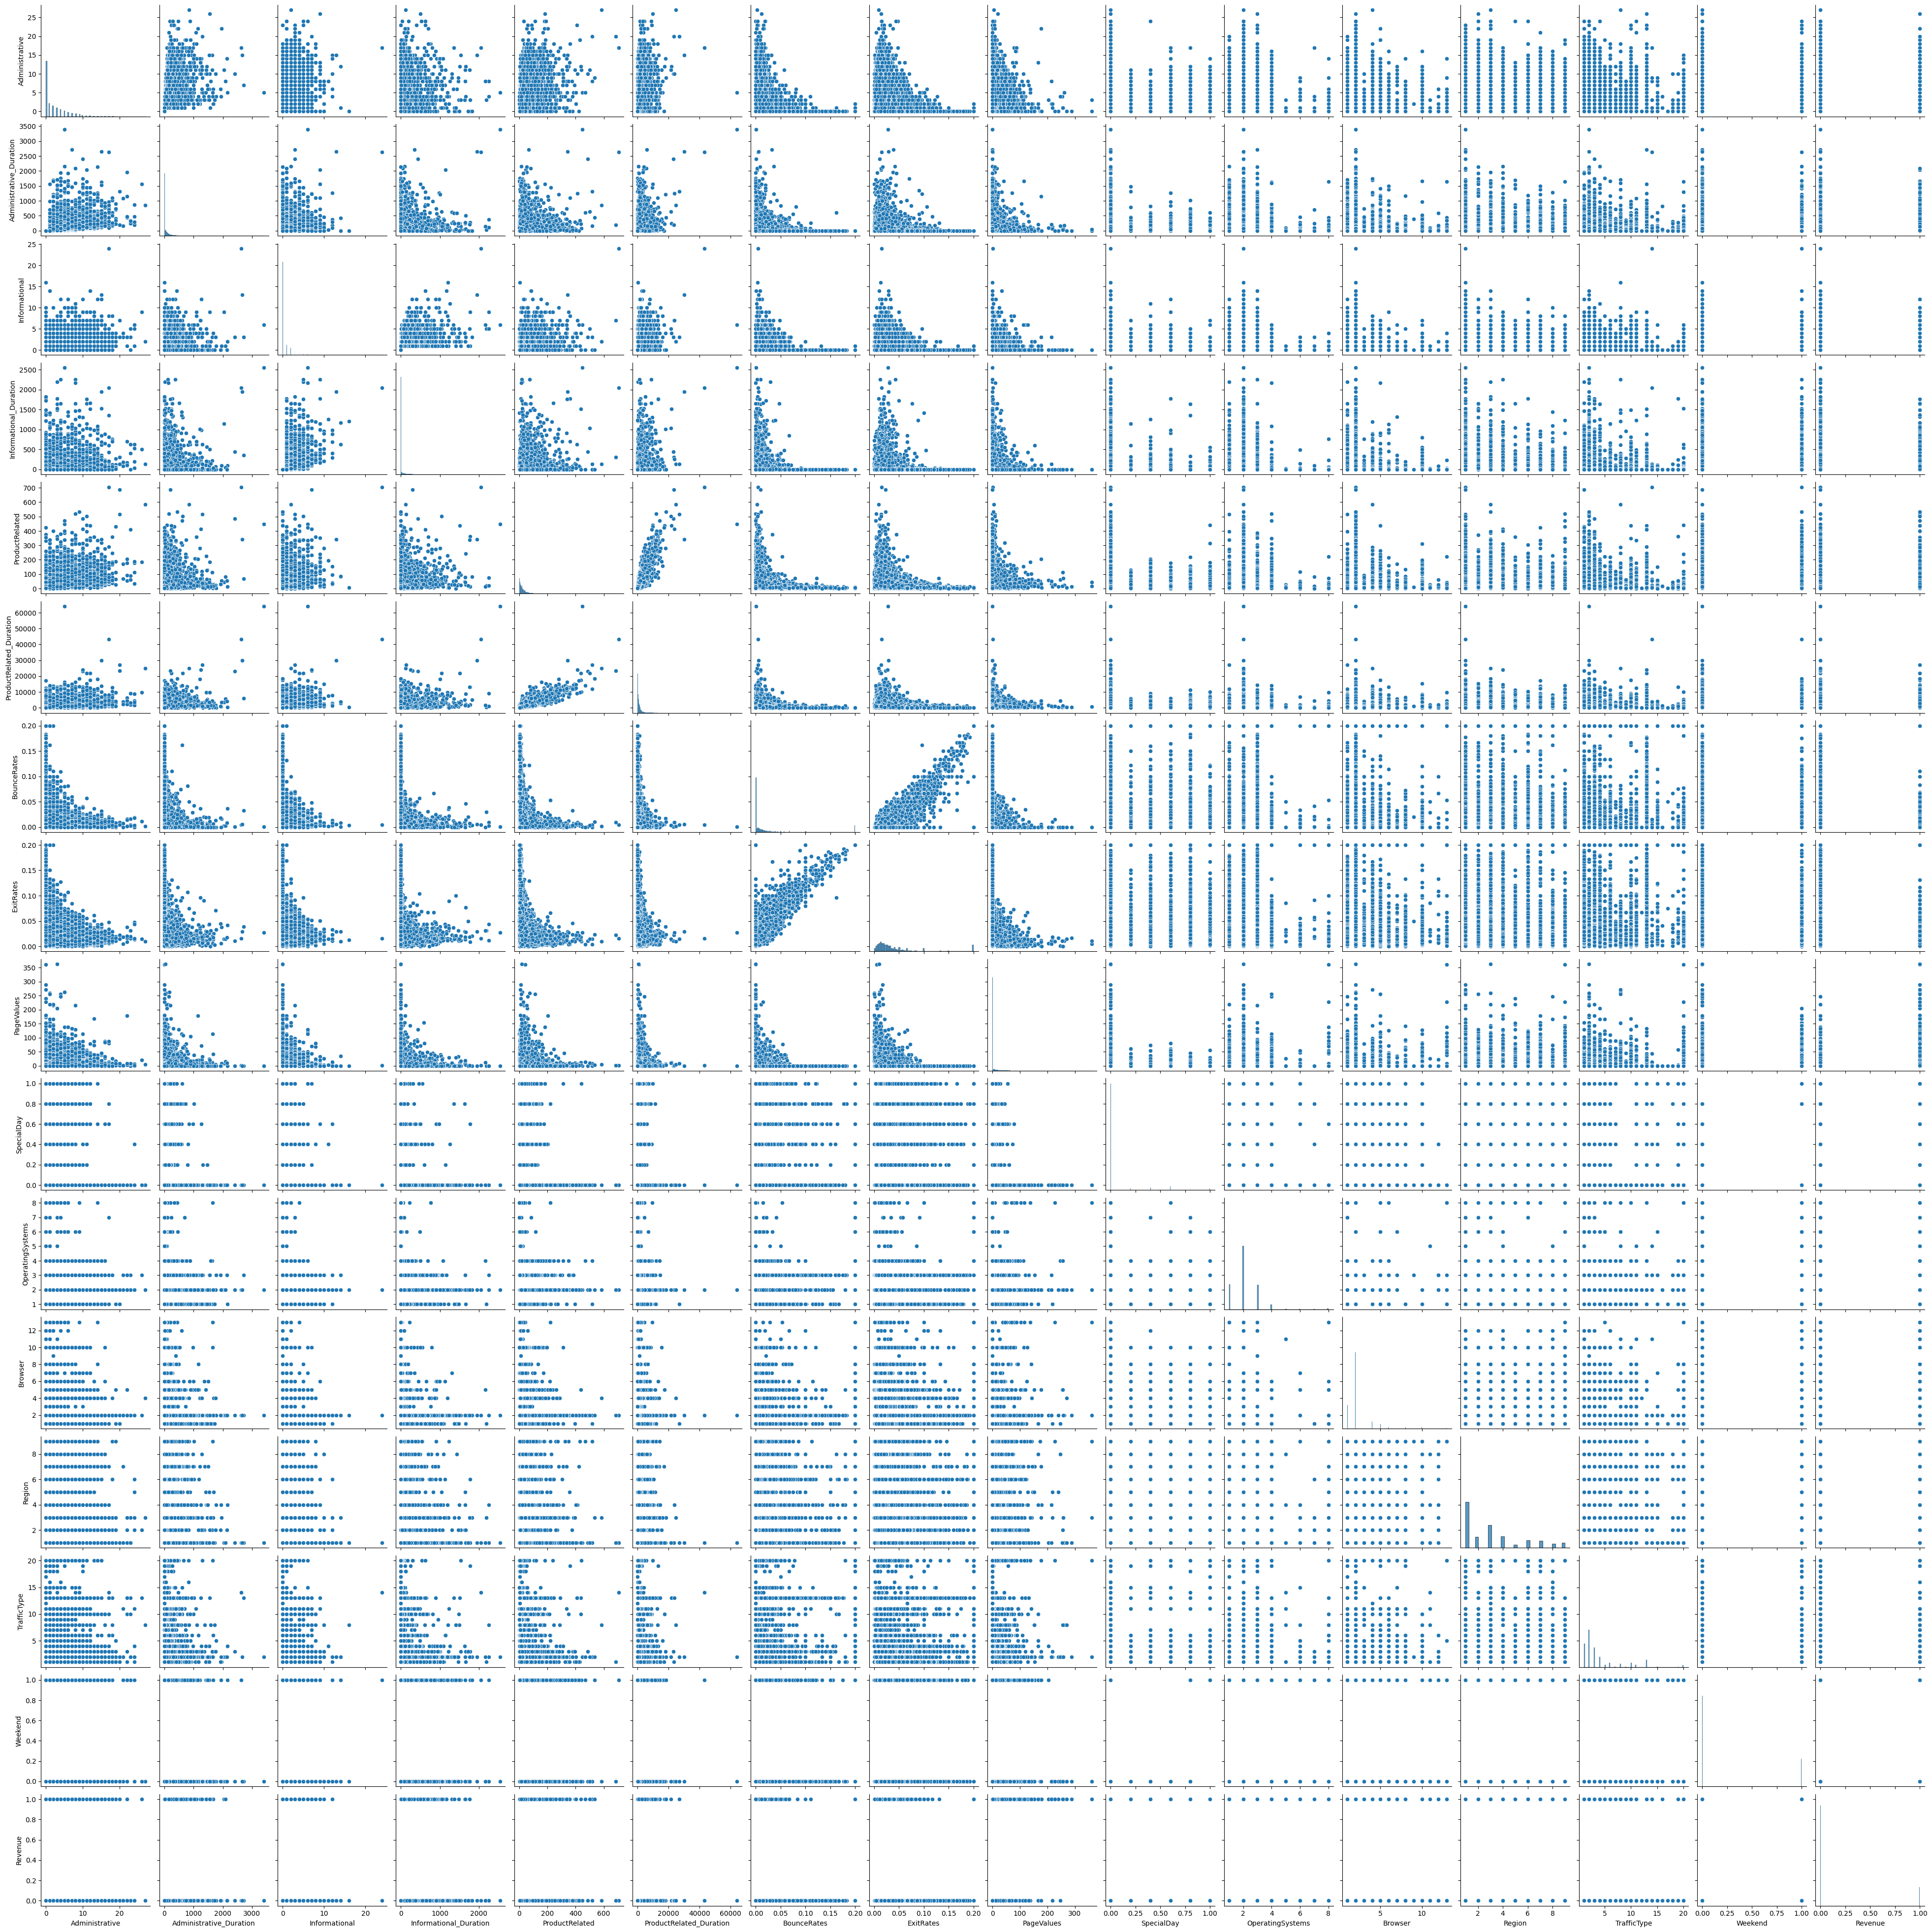

In [5]:
sns.pairplot(df[lst_col])
plt.show()

In [6]:
# - PageValues: khách có xem trang SẢN PHẨM GIÁ TRỊ CAO không? (mức độ quan tâm)
# - ExitRates: khách có DỄ BỎ ĐI ngay không? (mức độ rời bỏ)
behavior_features = ['PageValues', 'ExitRates']
print(df[behavior_features].describe())

         PageValues     ExitRates
count  12330.000000  12330.000000
mean       5.889258      0.043073
std       18.568437      0.048597
min        0.000000      0.000000
25%        0.000000      0.014286
50%        0.000000      0.025156
75%        0.000000      0.050000
max      361.763742      0.200000


In [7]:
X_cluster = df[behavior_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

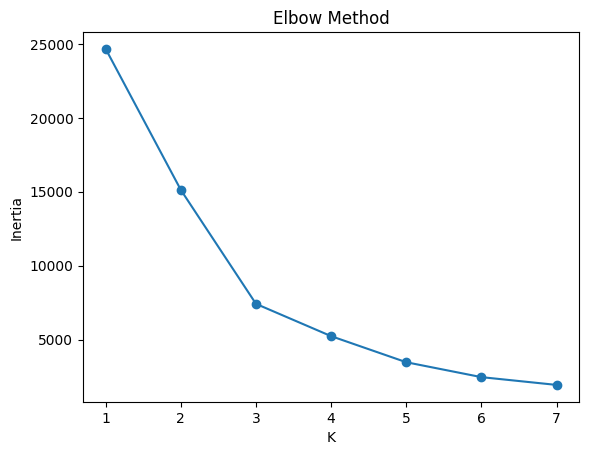

In [8]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,8), inertia, marker='o')
plt.xlabel('K'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.show()

In [9]:
# BƯỚC 1: K-Means phân khúc hành vi
behavior_features = ['ProductRelated_Duration','BounceRates','ExitRates','PageValues']
X_cluster = df[behavior_features]
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(X_cluster_scaled)
print(df.groupby('Segment')[behavior_features + ['Revenue']].mean())

         ProductRelated_Duration  BounceRates  ExitRates  PageValues   Revenue
Segment                                                                       
0                     858.077680     0.010104   0.033467    2.232937  0.110930
1                      46.412281     0.179463   0.187135    0.000000  0.005388
2                    1230.950117     0.003000   0.014661   65.196227  0.780726
3                    6307.398392     0.006527   0.020894    4.668762  0.297297


In [ ]:
# Segment 0: "Lướt qua, không quan tâm"
# Segment 1: "Đang tìm hiểu sản phẩm"
# Segment 2: "Ý định mua cao" (PageValues cao)
# Segment 3: "Dễ thoát trang"

In [10]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Segment
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False,0


In [14]:
df['Segment'].unique()

array([1, 0, 2, 3], dtype=int32)

In [23]:
df.groupby('Segment')[['PageValues','ExitRates']].mean()

,PageValues,ExitRates
Segment,,
0,2.232937,0.033467
1,0.000000,0.187135
2,65.196227,0.014661
3,4.668762,0.020894


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# BƯỚC 2: Dự đoán Revenue bằng nhóm feature B — KHÔNG trùng với feature đã tạo Segment
# Dùng các cột mô tả THỜI LƯỢNG và BỐI CẢNH phiên truy cập (thông tin khác hẳn)
features_without_seg = ['Administrative_Duration', 'ProductRelated_Duration', 'Weekend']
y = df['Revenue'].astype(int)

X_no_seg = df[features_without_seg]
X_tr, X_te, y_tr, y_te = train_test_split(X_no_seg, y, test_size=0.2, random_state=42, stratify=y)
model_no_seg = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
print("Accuracy (không Segment):", round(accuracy_score(y_te, model_no_seg.predict(X_te)), 3))

# Thêm Segment vào — giờ đây Segment mang THÔNG TIN MỚI (chất lượng hành vi) 
# mà features_without_seg (thời lượng, bối cảnh) không có
X_with_seg = pd.get_dummies(df[features_without_seg + ['Segment']], columns=['Segment'], drop_first=True)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_with_seg, y, test_size=0.2, random_state=42, stratify=y)
model_with_seg = LogisticRegression(max_iter=1000).fit(X_tr2, y_tr2)
print("Accuracy (có Segment):", round(accuracy_score(y_te2, model_with_seg.predict(X_te2)), 3))

Accuracy (không Segment): 0.845
Accuracy (có Segment): 0.876


In [17]:
df['Revenue'].unique()

array([False,  True])

In [41]:

# ===== BƯỚC 1: K-Means phân khúc hành vi (bản gốc của bạn) =====
behavior_features = ['PageValues', 'ExitRates']
print(df[behavior_features].describe())

X_cluster = df[behavior_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(X_scaled)

# ----- Thông tin khách hàng mới -----
new_customer = {
    'Administrative_Duration': 80,
    'ProductRelated_Duration': 900,
    'Weekend': 1,
    'PageValues': 35,
    'ExitRates': 0.02
}

# ----- Bước 1: Dự đoán Segment khách hàng thuộc về -----
customer_behavior = pd.DataFrame([{
    'PageValues': new_customer['PageValues'],
    'ExitRates': new_customer['ExitRates']
}])

customer_scaled = scaler.transform(customer_behavior)   # dùng đúng scaler đã fit ở trên
predicted_segment = kmeans.predict(customer_scaled)[0]
print("Khách hàng thuộc Segment:", predicted_segment)

# ----- Bước 2: Chuẩn bị dữ liệu đầu vào cho model_with_seg -----
row = pd.DataFrame([{
    'Administrative_Duration': new_customer['Administrative_Duration'],
    'ProductRelated_Duration': new_customer['ProductRelated_Duration'],
    'Weekend': new_customer['Weekend'],
    f'Segment_{predicted_segment}': 1
}]).reindex(columns=X_with_seg.columns, fill_value=0)

# ----- Bước 3: Dự đoán xác suất mua hàng -----
proba = model_with_seg.predict_proba(row)[0][1] * 100
print("Xác suất mua hàng:", round(proba, 1), "%")

# ----- Bước 4: Dự đoán nhãn mua / không mua -----
label = model_with_seg.predict(row)[0]
print("Dự đoán:", "Có mua hàng" if label == 1 else "Không mua hàng")


         PageValues     ExitRates
count  12330.000000  12330.000000
mean       5.889258      0.043073
std       18.568437      0.048597
min        0.000000      0.000000
25%        0.000000      0.014286
50%        0.000000      0.025156
75%        0.000000      0.050000
max      361.763742      0.200000
Khách hàng thuộc Segment: 2
Xác suất mua hàng: 79.7 %
Dự đoán: Có mua hàng
